In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stan
from pathlib import Path
from scipy.stats import gaussian_kde

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load stability and nnd metrics
df = pd.read_csv('processed_data/stability_ALL.csv', parse_dates=['date_now', 'date_prev'])
df2 = pd.read_csv('processed_data/nnd_ALL.csv')

## Factor ordering + labels
lek_order = ['Velavadar_LEK1', 'Velavadar_LEK2', 'TalChhapar_TC']
lek_labels = {'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2','TalChhapar_TC': 'Tal Chhapar'}

df['lek_id'] = (pd.Categorical(df['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))
df2['lek_id'] = (pd.Categorical(df2['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))

In [4]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

lek_labels = df['lek_id'].cat.categories.tolist()

In [5]:
df2['date'] = pd.to_datetime(df2['date'])
df2 = df2[['lek_id', 'date', 'nnd_count']].dropna().copy()

df = df[['lek_id', 'date_now', 'mode_shift']].dropna().copy()
df = df.sort_values(['lek_id', 'date_now']).reset_index(drop=True)

## Serialise and centre the date / time
t0 = df['date_now'].min()
df['t_years'] = (df['date_now'] - t0).dt.days / 365.25
df['t_centred'] = df['t_years'] - df['t_years'].mean()
df2['t_years'] = (df2['date'] - t0).dt.days / 365.25
df2['t_centred'] = df2['t_years'] - df2['t_years'].mean()

## Log transform nnd columns to construct a log-normal model
df['log_mode_shift'] = np.log(df['mode_shift'].astype(float))

## Encode lek ID in a numerical variable
lek_levels = sorted(df['lek_id'].unique())
lek_map = {lek: i + 1 for i, lek in enumerate(lek_levels)}
df['site_id'] = df['lek_id'].map(lek_map).astype(int)

In [6]:
## Specify time axis
t_min, t_max = float(df['t_centred'].min()), float(df['t_centred'].max())
t_grid = np.linspace(t_min, t_max, 200)
t_years = t_grid + df['t_years'].mean()
date_grid = t0 + pd.to_timedelta(t_years * 365.25, unit='D')

In [7]:
## 1) Total effect of time on site mode
shift_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  
  array[n_points] int<lower=1,upper=n_sites> site_id;
  
  vector[n_points] t;
  vector[n_points] y;
}

parameters {
  vector[n_sites] alpha;
  vector[n_sites] beta_before;
  
  vector[n_sites] delta_raw;
  real mu_delta;
  real<lower=0> tau_delta;

  real break_point;
  
  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] delta = mu_delta + tau_delta * delta_raw;
  
  vector[n_points] mu_conditional;
  for (n in 1:n_points) {
    mu_conditional[n] = alpha[site_id[n]] + beta_before[site_id[n]] * t[n] + delta[site_id[n]] * fmax(0, t[n] - break_point);
  }
}

model {
  alpha ~ normal(0, 10);
  beta_before ~ normal(0, 1);

  delta_raw ~ normal(0, 1);
  mu_delta ~ normal(0, 1);
  tau_delta ~ exponential(1);
  
  break_point ~ normal(0, 2);
  sigma ~ exponential(1);

  for (n in 1:n_points) {
    y[n] ~ normal(mu_conditional[n], sigma);
  }
}
"""

In [8]:
shift_data = {
    'n_points': len(df),
    'n_sites': int(df['site_id'].nunique()),
    'site_id': df['site_id'].astype(int).to_numpy(),
    't': df['t_centred'].astype(float).to_numpy(),
    'y': df['log_mode_shift'].astype(float).to_numpy()
}

posterior = stan.build(shift_mod, data=shift_data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: 0.1s
Building: 0.2s
Building: 0.3s
Building: 0.4s
Building: 0.5s
Building: 0.6s
Building: 0.7s
Building: 0.9s
Building: 1.0s
Building: 1.1s
Building: 1.2s
Building: 1.3s
Building: 1.4s
Building: 1.5s
Building: 1.6s
Building: 1.7s
Building: 1.8s
Building: 1.9s
Building: 2.0s
Building: 2.1s
Building: 2.2s
Building: 2.3s
Building: 2.4s
Building: 2.5s
Building: 2.6s
Building: 2.7s
Building: 2.8s
Building: 2.9s
Building: 3.1s
Building: 3.2s
Building: 3.3s
Building: 3.4s
Building: 3.5s
Building: 3.6s
Building: 3.7s
Building: 3.8s
Building: 3.9s
Building: 4.0s
Building: 4.1s
Building: 4.2s
Building: 4.3s
Building: 4.4s
Building: 4.5s
Building: 4.6s
Building: 4.7s
Building: 4.8s
Building: 4.9s
Building: 5.0s
Building: 5.1s
Building: 5.2s
Building: 5.4s
Building: 5.5s
Building: 5.6s
Building: 5.7s
Building: 5.8s
Building: 5.9s
Building: 6.0s
Building: 6.1s
Building: 6.2s
Building: 6.3s
Building: 6.4s
Building: 6.5s
Building: 6.6s
Building: 6.7s
Building: 6.8s
Building: 6.9s
Building: 

In file included from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_ccdf_log.hpp:5,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob.hpp:331,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim.hpp:16,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:16,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math.hpp:19,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/model/model_header.hpp:4,
                 from /home/vivek/.cache/httpstan/4.13.0/models/yumrhnaj/model_yumrhnaj.cpp:2:
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_lccdf.hpp: In function ‘stan::return_typ

Building: 10.6s
Building: 10.7s
Building: 10.8s
Building: 10.9s
Building: 11.0s
Building: 11.1s
Building: 11.2s
Building: 11.3s
Building: 11.4s
Building: 11.5s
Building: 11.6s
Building: 11.7s
Building: 11.9s
Building: 12.0s


In file included from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/tbb/concurrent_unordered_map.h:26,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core/profiling.hpp:10,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core.hpp:53,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:10:
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/tbb/internal/_concurrent_unordered_impl.h: In instantiation of ‘void tbb::interface5::internal::concurrent_unordered_base<Traits>::internal_init() [with Traits = tbb::interface5::concurrent_unordered_map_traits<std::pair<std::basic_string<char>, std::thread::id>, stan::math::profile_info, tbb::interface5::internal::hash_compare<std::pair<std::basic_string<char>, std::thread::id>, stan::math::internal::hash_p

Building: 12.1s
Building: 12.2s
Building: 12.3s
Building: 12.4s
Building: 12.5s
Building: 12.6s
Building: 12.7s
Building: 12.8s
Building: 12.9s
Building: 13.0s
Building: 13.1s
Building: 13.2s
Building: 13.3s
Building: 13.4s
Building: 13.5s
Building: 13.6s
Building: 13.7s
Building: 13.8s
Building: 14.0s
Building: 14.1s
Building: 14.2s
Building: 14.3s
Building: 14.4s
Building: 14.5s
Building: 14.6s
Building: 14.7s
Building: 14.8s
Building: 14.9s
Building: 15.0s
Building: 15.1s
Building: 15.2s
Building: 15.3s
Building: 15.4s
Building: 15.5s
Building: 15.6s
Building: 15.7s
Building: 15.8s
Building: 15.9s
Building: 16.0s
Building: 16.1s
Building: 16.3s
Building: 16.4s
Building: 16.5s
Building: 16.6s
Building: 16.7s
Building: 16.8s
Building: 16.9s
Building: 17.0s
Building: 17.1s
Building: 17.2s
Building: 17.3s
Building: 17.4s
Building: 17.5s
Building: 17.6s
Building: 17.7s
Building: 17.8s
Building: 17.9s
Building: 18.0s
Building: 18.1s
Building: 18.2s
Building: 18.3s
Building: 18.4s
Building

Building: 24.1s, done.
Sampling:   0%
Sampling:   8% (600/8000)
Sampling:  32% (2600/8000)
Sampling:  58% (4600/8000)
Sampling:  82% (6600/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 3.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.36 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.7e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.27 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 4.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.42 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: normal_lpdf: Location parameter is -nan, but must be finite! (in '/tmp/httpstan_4lx1lmh9/model_yumrhnaj.stan', line 47, column 4 to col

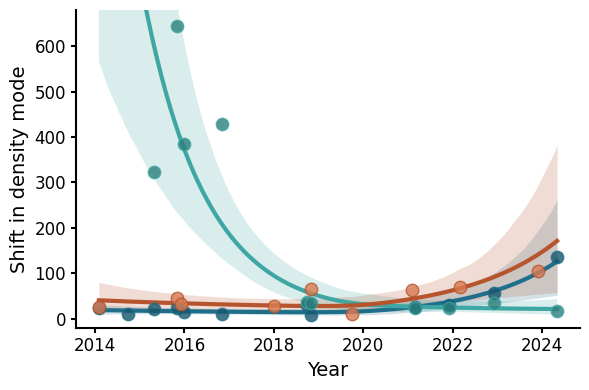

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior mean shift in density model 
    mu = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta_before'][site_id,:].reshape(-1,1) * t_grid[None, :] + fit['delta'][site_id,:].reshape(-1,1) * np.maximum(0, t_grid[None, :] - fit['break_point'].reshape(-1,1))
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025, 0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot
    ax.scatter(df_lek['date_now'], df_lek['mode_shift'], s=80, color=point_cols.get(lek), edgecolor=fill_cols.get(lek), alpha=0.8, zorder=4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('Shift in density mode (m)', fontsize=14)
    ax.set_ylim(-20,680)

plt.tight_layout()
plt.savefig(out_dir/'mod_site_stability.png', dpi=300, bbox_inches='tight')

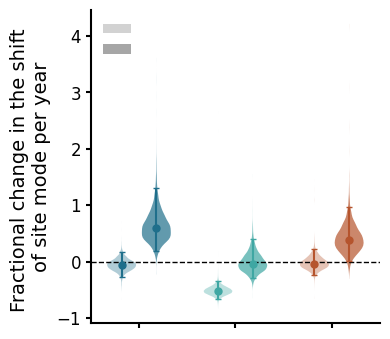

In [12]:
fig, ax = plt.subplots(figsize=(4, 3.5))

# x-positions for categorical variables
x_pos = np.arange(len(lek_labels))
offset = 0.18

for i, lek in enumerate(lek_labels):
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute causal effect distribution (fractional yearly change)
    samples_before = np.exp(fit['beta_before'][site_id, :]) - 1
    samples_after  = np.exp(fit['beta_after'][site_id, :]) - 1

    for samples,dx,alpha in [(samples_before, -offset, 0.35), (samples_after, offset, 0.70)]:
        xpos = x_pos[i] + dx

        # Violin plot
        parts = ax.violinplot(samples, positions=[xpos], widths=0.30, showmeans=False, showmedians=False, showextrema=False)

        for pc in parts['bodies']:
            pc.set_facecolor(fill_cols.get(lek))
            pc.set_edgecolor('none')
            pc.set_alpha(alpha)

        # Overlay median + 95% credible interval
        median = np.median(samples)
        lower, upper = np.quantile(samples, [0.025, 0.975])

        ax.errorbar(xpos, median, yerr=[[median - lower], [upper - median]], fmt='o', color=fill_cols.get(lek), markersize=5, capsize=2, zorder=3)

ax.axhline(0, linestyle='--', color='black', linewidth=1)
ax.set_xlim(-0.5, len(lek_labels) - 0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([])

ax.set_ylabel('Fractional change in the shift \nof site mode per year',fontsize=14)

# Legend for before/after
from matplotlib.patches import Patch

legend_elements = [Patch(facecolor='grey', alpha=0.35), Patch(facecolor='grey', alpha=0.70)]
ax.legend(handles=legend_elements, frameon=False, fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'mod_causal_site_stability.png', dpi=300, bbox_inches='tight')